In [5]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.visualization import simple_norm

from spectral_cube import SpectralCube as sc
from regions import RectangleSkyRegion
from tqdm.notebook import tqdm

from pybaselines import Baseline

import os
import tempfile
from concurrent.futures import ProcessPoolExecutor

# disable the Parameter Warning
import warnings
from pybaselines.utils import ParameterWarning
warnings.filterwarnings("ignore", category=ParameterWarning)

%matplotlib widget

%matplotlib widget

import sys
print(sys.version)
print(sys.executable)

3.13.11 | packaged by conda-forge | (main, Dec  6 2025, 11:24:03) [GCC 14.3.0]
/home/firestar/.miniforge/bin/python


In [6]:
def displayimage(cube, region=None):
    img = cube.moment(order=0).value  # moment 0
    fig, ax = plt.subplots(
        figsize=(5, 3), layout="compressed", subplot_kw={"projection": cube.wcs.celestial}
    )
    norm = simple_norm(np.array(img), vmin=0, vmax=np.max(img), stretch="linear")
    im = ax.imshow(img, norm=norm, cmap="viridis_r", origin="lower")
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter("dd")
    lat.set_major_formatter("dd")
    lon.set_axislabel("RA")
    lat.set_axislabel("Dec")
    if region != None:
        region.plot(color="white")
    plt.colorbar(im)
    plt.show()

In [ ]:
# Combine CRAFTS data cubes
# Test (positive): xlo=113*u.deg, xhi=125*u.deg, ylo=-13*u.deg, yhi=-7*u.deg, zlo=100 * u.km/u.s, zhi=300 * u.km/u.s
# Test (negative): xlo=60*u.deg, xhi=80*u.deg, ylo=-6*u.deg, yhi=-2*u.deg, zlo=-255 * u.km/u.s, zhi=-55 * u.km/u.s

file1 = "../CRAFTS/South/00_DEC_-13.0_-3.0__11_RA_110.0_120.0__-600kms_600kms.I.fits"  # -10 ~ -30
file2 = "../CRAFTS/South/00_DEC_-13.0_-3.0__12_RA_120.0_130.0__-600kms_600kms.I.fits"  # 10 ~ -10

cube1 = sc.read(file1)
subcube1 = cube1.subcube(zlo=100 * u.km/u.s, zhi=300 * u.km/u.s)
print(subcube1)
data1 = subcube1.unmasked_data[:, :, :]
data1 = np.nan_to_num(data1)
del cube1

cube2 = sc.read(file2)
subcube2 = cube2.subcube(zlo=100 * u.km/u.s, zhi=300 * u.km/u.s)
print(subcube2)
data2 = subcube2.unmasked_data[:, :, :]
data2 = np.nan_to_num(data2)
del cube2

SpectralCube with shape=(995, 400, 400) and unit=K:
 n_x:    400  type_x: RA---CAR  unit_x: deg    range:   110.012500 deg:  119.987500 deg
 n_y:    400  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:   -3.012500 deg
 n_s:    995  type_s: VRAD      unit_s: m / s  range:    99965.887 m / s:  300041.780 m / s
SpectralCube with shape=(995, 400, 400) and unit=K:
 n_x:    400  type_x: RA---CAR  unit_x: deg    range:   120.012500 deg:  129.987500 deg
 n_y:    400  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:   -3.012500 deg
 n_s:    995  type_s: VRAD      unit_s: m / s  range:    99965.887 m / s:  300041.780 m / s


SpectralCube with shape=(995, 241, 481) and unit=K:
 n_x:    481  type_x: RA---CAR  unit_x: deg    range:   112.987500 deg:  124.987500 deg
 n_y:    241  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:   -6.987500 deg
 n_s:    995  type_s: VRAD      unit_s: m / s  range:    99965.887 m / s:  300041.780 m / s


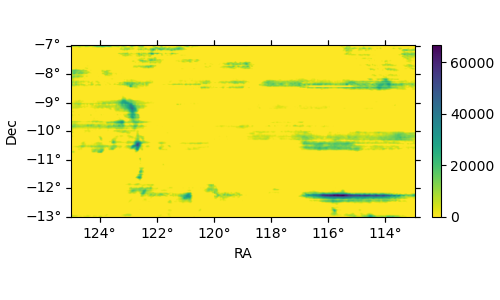

In [8]:
# Combine the images
combined_data = np.concatenate((data2, data1), axis=2)

# Update the header for the new combined image
combined_header = subcube2.wcs.to_header()
combined_wcs = WCS(combined_header)

combined_cube = sc(data=combined_data, wcs=combined_wcs)

crafts_cube = combined_cube.subcube(xlo=113*u.deg, xhi=125*u.deg, ylo=-13*u.deg, yhi=-7*u.deg)
crafts_cube.write("test.fits", format="fits", overwrite=True)

print(crafts_cube)
displayimage(crafts_cube)

In [10]:
# limit BLAS/OMP threads BEFORE importing numpy/scipy
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

# Ensure Baseline is importable at module scope
# from your_baseline_module import Baseline

# Parameters you must provide:
#   dataset : np.ndarray shaped (n_rows, n_v)
#   velocities : 1D array for Baseline(x_data=velocities)
#   lam : baseline parameter (optional)
#   chunksize : map chunksize (tune: 64/128/256)
#
# Example:
#   dataset = data.transpose(1,2,0).reshape(n_y*n_x, n_v)
#   velocities = velocities
#   lam = 1e8

def _init_worker(mem_in, shape_in, dtype_in, mem_out, shape_out, dtype_out, velocities):
    # worker initializer: open memmaps and create Baseline instance once
    global MEM_IN, MEM_OUT, WORKER_BASELINE
    MEM_IN = np.load(mem_in, mmap_mode="r")
    MEM_OUT = np.lib.format.open_memmap(mem_out, mode="r+")
    WORKER_BASELINE = Baseline(x_data=velocities)

def _fit_and_write(i, lam=1e8):
    # compute baseline for row i and write it directly into the output memmap
    y = MEM_IN[i]
    bkg, _ = WORKER_BASELINE.arpls(y, lam=lam)
    MEM_OUT[i] = bkg  # safe: each worker writes its own row
    return None  # small/cheap return to avoid pickling large results

def compute_baselines(dataset, velocities, lam=1e8, chunksize=256, max_workers=None):
    max_workers = max_workers or (os.cpu_count() or 1)

    # create input .npy memmap if not already present
    mem_in = os.path.join(tempfile.gettempdir(), "dataset_for_baseline.npy")
    if not os.path.exists(mem_in):
        np.save(mem_in, dataset)  # one-time write

    # create output memmap file (writable) with same n_rows x n_v shape
    n_rows, n_v = dataset.shape
    mem_out = os.path.join(tempfile.gettempdir(), "baselines_out.npy")
    if not os.path.exists(mem_out):
        out = np.lib.format.open_memmap(mem_out, mode="w+", dtype=dataset.dtype, shape=(n_rows, n_v))
        out[:] = 0
        del out

    # run ProcessPoolExecutor with initializer that maps memmaps & creates Baseline
    with ProcessPoolExecutor(
        max_workers=max_workers,
        initializer=_init_worker,
        initargs=(mem_in, dataset.shape, dataset.dtype, mem_out, (n_rows, n_v), dataset.dtype, velocities),
    ) as ex:
        # map returns results in order; iterate to ensure completion and show progress
        for _ in tqdm(ex.map(_fit_and_write, range(n_rows), chunksize=chunksize),
                      total=n_rows, desc="fitting baselines"):
            pass

    # load output (memory-map for low memory) and return
    return np.load(mem_out, mmap_mode="r")


crafts_data = crafts_cube.unmasked_data[:, :, :].value
n_v, n_y, n_x = crafts_data.shape
velocities = crafts_cube.spectral_axis.value
dataset = crafts_data.transpose(1, 2, 0).reshape(n_y * n_x, n_v)  # shape (480000, len(velocities))
baselines = compute_baselines(dataset, velocities, lam=1e8, chunksize=256, max_workers=os.cpu_count())

fitting baselines:   0%|          | 0/115921 [00:00<?, ?it/s]

SpectralCube with shape=(995, 241, 481) and unit=K:
 n_x:    481  type_x: RA---CAR  unit_x: deg    range:   112.987500 deg:  124.987500 deg
 n_y:    241  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:   -6.987500 deg
 n_s:    995  type_s: VRAD      unit_s: m / s  range:    99965.887 m / s:  300041.780 m / s


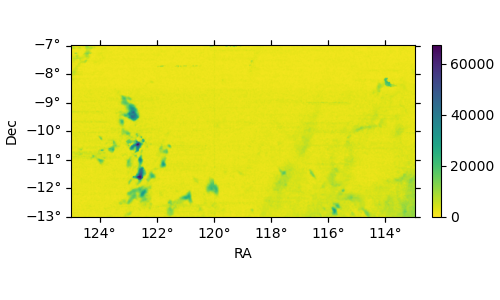

In [12]:
baselines = baselines.T.reshape(n_v, n_y, n_x)
corrected = crafts_data - baselines
corrected = corrected << u.K
corrected_cube = sc(data=corrected, wcs=crafts_cube.wcs)

print(corrected_cube)
displayimage(corrected_cube)

In [15]:
hi4pi_cube = sc.read("../HI4PI/HI4PI_ALLSKY_EQ2000_CAR.fits")
hi4pi_test_cube = hi4pi_cube.subcube(xlo=113*u.deg, xhi=125*u.deg, ylo=-13*u.deg, yhi=-7*u.deg, zlo=100 * u.km/u.s, zhi=300 * u.km/u.s)
print(hi4pi_test_cube)
del hi4pi_test_cube.header["SLICE"]
hi4pi_test_cube.write("hi4pi_test.fits", format="fits", overwrite=True)

SpectralCube with shape=(156, 73, 145) and unit=K:
 n_x:    145  type_x: RA---CAR  unit_x: deg    range:   113.000000 deg:  125.000000 deg
 n_y:     73  type_y: DEC--CAR  unit_y: deg    range:   -13.000000 deg:   -7.000000 deg
 n_s:    156  type_s: VRAD      unit_s: m / s  range:   100581.725 m / s:  300255.045 m / s


In [16]:
# Reproject HI4PI test cube to CRAFTS test cube
reprojected_file = "./hi4pi_test_reprojected.fits"

target_header = crafts_cube.wcs.celestial.to_header()

target_header['NAXIS'] = hi4pi_test_cube.ndim
target_header['NAXIS1'] = crafts_cube.shape[2]
target_header['NAXIS2'] = crafts_cube.shape[1]
target_header['NAXIS3'] = hi4pi_test_cube.shape[0]
target_header['CTYPE3'] = hi4pi_test_cube.wcs.wcs.ctype[2]
target_header['CDELT3'] = hi4pi_test_cube.wcs.wcs.cdelt[2]
target_header['CRPIX3'] = hi4pi_test_cube.wcs.wcs.crpix[2]
target_header['CRVAL3'] = hi4pi_test_cube.wcs.wcs.crval[2]
target_header['CUNIT3'] = "m/s"

reprojected_cube = hi4pi_test_cube.reproject(target_header, parallel=True)
reprojected_cube.write(reprojected_file, overwrite=True)